# Note that this project takes place in R

<center><img src="football.jpg" width=500></center>

The Super Bowl is a spectacle. It is the final game in the NFL that crowns the winner of that season. There is always a little something for everyone. For the fans, there is the game itself. For those tagging along, there are the unique advertisements and the halftime shows with the biggest musicians in the world.

You're going to explore how these elements interact.

## The Data
The data has been scraped from Wikipedia and is made up of two CSV files covering a span of all Super Bowls up to 2024. This data does contain missing values. The most relevant columns are noted below.  
`data/tv.csv`  
|Column|Description|
|------|-----------|
|`super_bowl`|Super Bowl number (e.g. the first Super Bowl ever is Super Bowl 1 and the last Super Bowl in 2024 is Super Bowl 58)|
|`avg_us_viewers`|Average # of US viewers|
|`share_household`|Percentage of households watching TV that watched the game|
|`rating_household`|Percentage of all households with TVs that watched the game|
|`ad_cost`|Cost per ad|
---
`data/super_bowls.csv`  
|Column|Description|
|------|-----------|
|`super_bowl`|Super Bowl number (e.g. the first Super Bowl ever is Super Bowl 1 and the last Super Bowl in 2024 is Super Bowl 58)|
|`difference_pts`|Point difference for that game|

# Objectives
Understand how Super Bowl scores, viewership, and advertisements interact with each other by answering the following questions:
1) Do large point differences result in lost viewers across super bowl games? Visualize and interpret the data, storing your string answer to `score_impact` (either "strong", "weak", or "none").

2) How has the number of viewers and TV ratings trended alongside advertisement costs? Which one increases first? Visualize and interpret the data, storing your string answer to `first_to_increase` (either "viewers", "ratings", or "ads").

In [191]:
# Load packages
library(tidyverse)
library(ggplot2)


In [192]:
# Load the CSV data
tv  <-  read_csv("tv.csv", show_col_types=FALSE)
super_bowls  <-  read_csv("super_bowls.csv", show_col_types=FALSE)

tv

super_bowl,network,avg_us_viewers,total_us_viewers,rating_household,share_household,rating_18_49,share_18_49,ad_cost
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
58,CBS,120230000,NA,42.1,81,35.9,111,7000000
57,Fox,114210000,NA,40.4,NA,33.8,NA,7000000
56,NBC,99180000,NA,36.9,72,29.5,NA,6500000
55,CBS,95200000,NA,38.2,68,26.5,88,5500000
54,Fox,101320000,NA,41.6,69,30.1,77,5400000
53,CBS,98480000,NA,41.1,67,31.0,78,5200000
52,NBC,103470000,NA,43.1,68,33.4,78,5200000
51,Fox,111319000,172000000,45.3,73,37.1,79,5000000
50,CBS,111864000,167000000,46.6,72,37.7,79,5000000


In [193]:
super_bowls

date,super_bowl,venue,city,state,attendance,team_winner,winning_pts,qb_winner_1,qb_winner_2,coach_winner,team_loser,losing_pts,qb_loser_1,qb_loser_2,coach_loser,combined_pts,difference_pts
<date>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
2024-02-11,58,Allegiant Stadium,Paradise,Nevada,61629,Kansas City Chiefs,25,Patrick Mahomes,NA,Andy Reid,San Francisco 49ers,22,Brock Purdy,NA,Kyle Shanahan,47,3
2023-02-12,57,State Farm Stadium,Glendale,Arizona,67827,Kansas City Chiefs,38,Patrick Mahomes,NA,Andy Reid,Philadelphia Eagles,35,Jalen Hurts,NA,Nick Sirianni,73,3
2022-02-13,56,SoFi Stadium,Inglewood,California,70048,Los Angeles Rams,23,Matthew Stafford,NA,Sean McVay,Cincinnati Bengals,20,Joe Burrow,NA,Zac Taylor,43,3
2021-02-07,55,Raymond James Stadium,Tampa,Florida,24835,Tampa Bay Buccaneers,31,Tom Brady,NA,Bruce Arians,Kansas City Chiefs,9,Patrick Mahomes,NA,Andy Reid,40,22
2020-02-02,54,Hard Rock Stadium,Miami Gardens,Florida,62417,Kansas City Chiefs,31,Patrick Mahomes,NA,Andy Reid,San Francisco 49ers,20,Jimmy Garoppolo,NA,Kyle Shanahan,51,11
2019-02-03,53,Mercedes-Benz Stadium,Atlanta,Georgia,70081,New England Patriots,13,Tom Brady,NA,Bill Belichick,Los Angeles Rams,3,Jared Goff,NA,Sean McVay,16,10
2018-02-04,52,U.S. Bank Stadium,Minneapolis,Minnesota,67612,Philadelphia Eagles,41,Nick Foles,NA,Doug Pederson,New England Patriots,33,Tom Brady,NA,Bill Belichick,74,8
2017-02-05,51,NRG Stadium,Houston,Texas,70807,New England Patriots,34,Tom Brady,NA,Bill Belichick,Atlanta Falcons,28,Matt Ryan,NA,Dan Quinn,62,6
2016-02-07,50,Levi's Stadium,Santa Clara,California,71088,Denver Broncos,24,Peyton Manning,NA,Gary Kubiak,Carolina Panthers,10,Cam Newton,NA,Ron Rivera,34,14


The `tv` dataset has 59 rows & 19 variables. This is because Super Bowl I was covered by both CBS & NBC, whereas all the other games only have data for one network. The `super_bowl` dataset has 58 rows & 18 variables. There is data for 58 Super Bowls.  
Both datasets have appropriate data types, column names, & consistent values; however, there are some missing values. For the purposes of this analysis, the 'total_us_viewers' variable could be problematic given how many missing values it has (44 of 59 data points).

# Q1
Do large point differences result in lost viewers across super bowl games? Visualize and interpret the data, storing your string answer to `score_impact` (either "strong", "weak", or "none").

**Notes:**
- Need to merge the 2 tables together. note that the "tv.csv" has 1 more row than the "super_bowls.csv". This is because Super Bowl 1 was covered by both NBC & CBS (the only SB this happened). Could alter this for purposes of Q1 &/or Q2.

In [194]:
#Q1
q1_data <- tv %>%
    #join the 2 datasets
    full_join(super_bowls, by=c("super_bowl")) %>%
    #adjust "viewers" to millions
    mutate(avg_us_viewers_M = avg_us_viewers/1000000, total_us_viewers_M = total_us_viewers/1000000) %>%
    #select columns of interest
    select(super_bowl, date, network, avg_us_viewers_M, total_us_viewers_M, team_winner, winning_pts, team_loser, losing_pts, combined_pts, difference_pts)
q1_data


super_bowl,date,network,avg_us_viewers_M,total_us_viewers_M,team_winner,winning_pts,team_loser,losing_pts,combined_pts,difference_pts
<dbl>,<date>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
58,2024-02-11,CBS,120.230,NA,Kansas City Chiefs,25,San Francisco 49ers,22,47,3
57,2023-02-12,Fox,114.210,NA,Kansas City Chiefs,38,Philadelphia Eagles,35,73,3
56,2022-02-13,NBC,99.180,NA,Los Angeles Rams,23,Cincinnati Bengals,20,43,3
55,2021-02-07,CBS,95.200,NA,Tampa Bay Buccaneers,31,Kansas City Chiefs,9,40,22
54,2020-02-02,Fox,101.320,NA,Kansas City Chiefs,31,San Francisco 49ers,20,51,11
53,2019-02-03,CBS,98.480,NA,New England Patriots,13,Los Angeles Rams,3,16,10
52,2018-02-04,NBC,103.470,NA,Philadelphia Eagles,41,New England Patriots,33,74,8
51,2017-02-05,Fox,111.319,172.00,New England Patriots,34,Atlanta Falcons,28,62,6
50,2016-02-07,CBS,111.864,167.00,Denver Broncos,24,Carolina Panthers,10,34,14


`geom_smooth()` using formula = 'y ~ x'


[1] -0.2206621

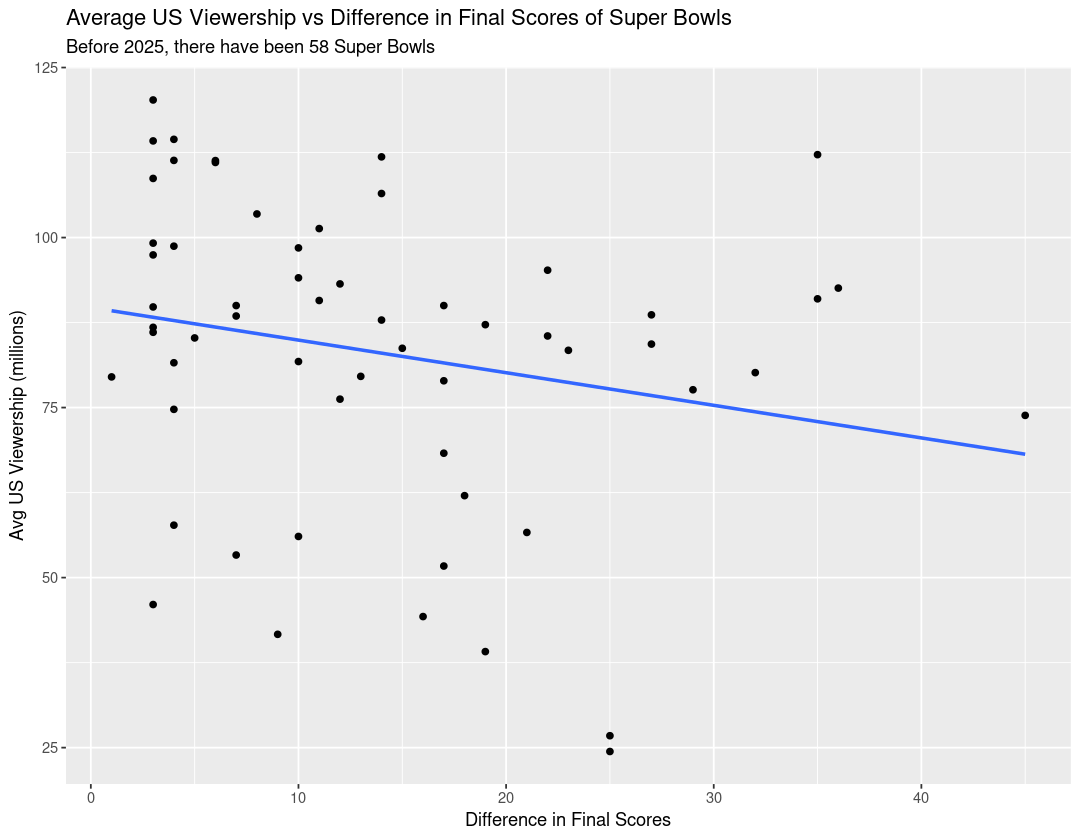

In [195]:
#Q1 cont.

#Plot AVG_US_VIEWERS (millions) vs DIFFERENCE_PTS
q1_plot_I <- ggplot(q1_data, aes(x=difference_pts, y=avg_us_viewers_M)) + 
    geom_point() + geom_smooth(method="lm", se=FALSE) + 
    labs(title="Average US Viewership vs Difference in Final Scores of Super Bowls", x="Difference in Final Scores", 
         y="Avg US Viewership (millions)", subtitle="Before 2025, there have been 58 Super Bowls") +
    theme(plot.title=element_text(size=11), plot.subtitle=element_text(size=10),
        axis.title.x=element_text(size=9), axis.title.y=element_text(size=9))
q1_plot_I

#calculate correlation between the variables
q1_corI <- cor(q1_data$difference_pts, q1_data$avg_us_viewers_M)
q1_corI
    #OUTPUT: -0.220662102212009 (not considerably meaningful)

Note that in the plot above, the variable along the vertical axis is in units of millions of viewers. This was done to make the values of this axis more readable.

From the plot above, there is a weak, negative relationship between "avg_us_viewers" & "difference_pts" (~ -0.221). Most Super Bowls have a relatively small final point differential (< ~20 points). In games with a very large final point differential (> 25), their average viewership is at least average or above. Typically, the games with the highest average viewership, have the smallest final point differentials.

As such, this small amount of information suggests a weak, negative relationship between viewership & the final point differential of a Super Bowl; less people watch the Super Bowl when the final score is not competitive.

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 44 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 44 rows containing missing values or values outside the scale range
(`geom_point()`).”


corr
<dbl>
-0.3760707


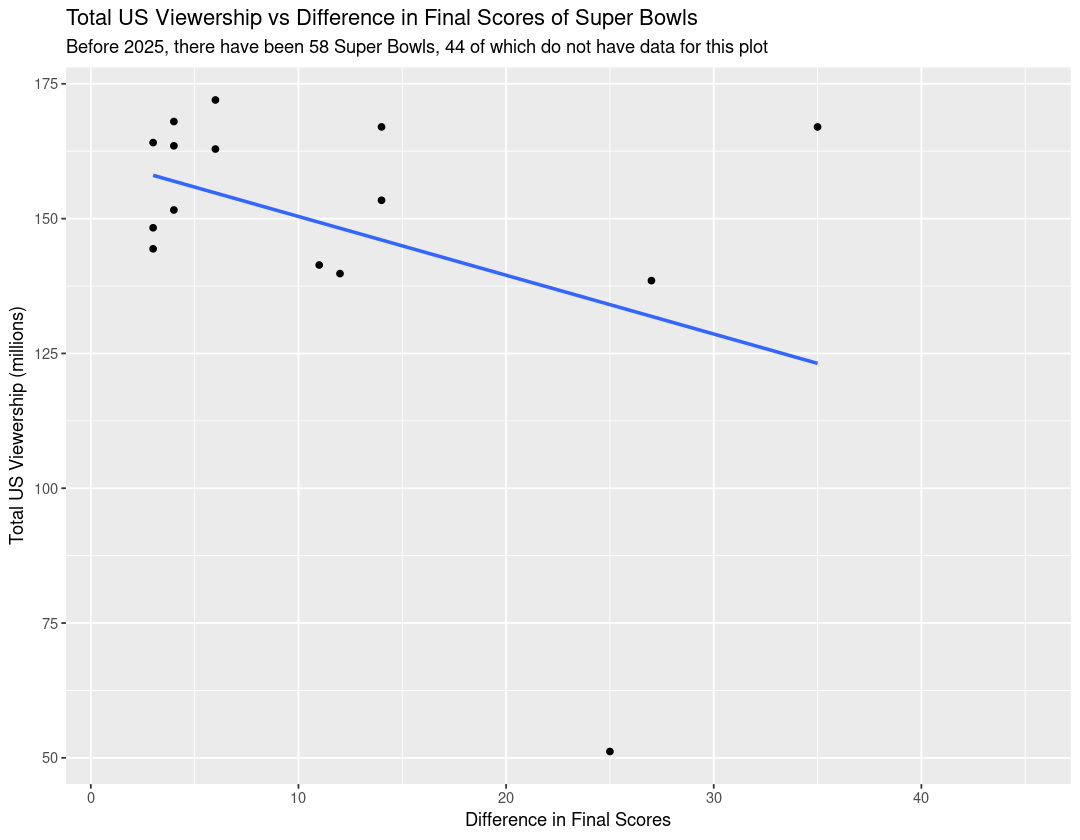

In [196]:
#Q1 cont.

#Plot TOTAL_US_VIEWERS (millions) vs DIFFERENCE_PTS
q1_plot_II <- ggplot(q1_data, aes(x=difference_pts, y=total_us_viewers_M)) + 
    geom_point() + geom_smooth(method="lm", se=FALSE) +
    labs(title="Total US Viewership vs Difference in Final Scores of Super Bowls", x="Difference in Final Scores", 
         y="Total US Viewership (millions)", 
         subtitle="Before 2025, there have been 58 Super Bowls, 44 of which do not have data for this plot") +
    theme(plot.title=element_text(size=11), plot.subtitle=element_text(size=10),
        axis.title.x=element_text(size=9), axis.title.y=element_text(size=9))
q1_plot_II

#calculate correlation between the variables -- need to filter out 'invalid' values
q1_corII <- q1_data %>%
    filter(!is.na(total_us_viewers_M)) %>%
    summarize(corr = cor(difference_pts, total_us_viewers_M))
q1_corII
    #OUTPUT: -0.37607

Note that in the plot above, the variable along the vertical axis is in units of millions of viewers. This was done to make the values of this axis more readable.

From the plot above, there is a fairly weak, negative relationship between "total_us_viewership" & "difference_pts" (~ -0.376). However, there are only 15 data points making up this data, & so it is not appropriate to draw any conclusions here. On the other hand, it does reaffirm the conclusions drawn from the previous plot which analyzed "avg_us_viewership."

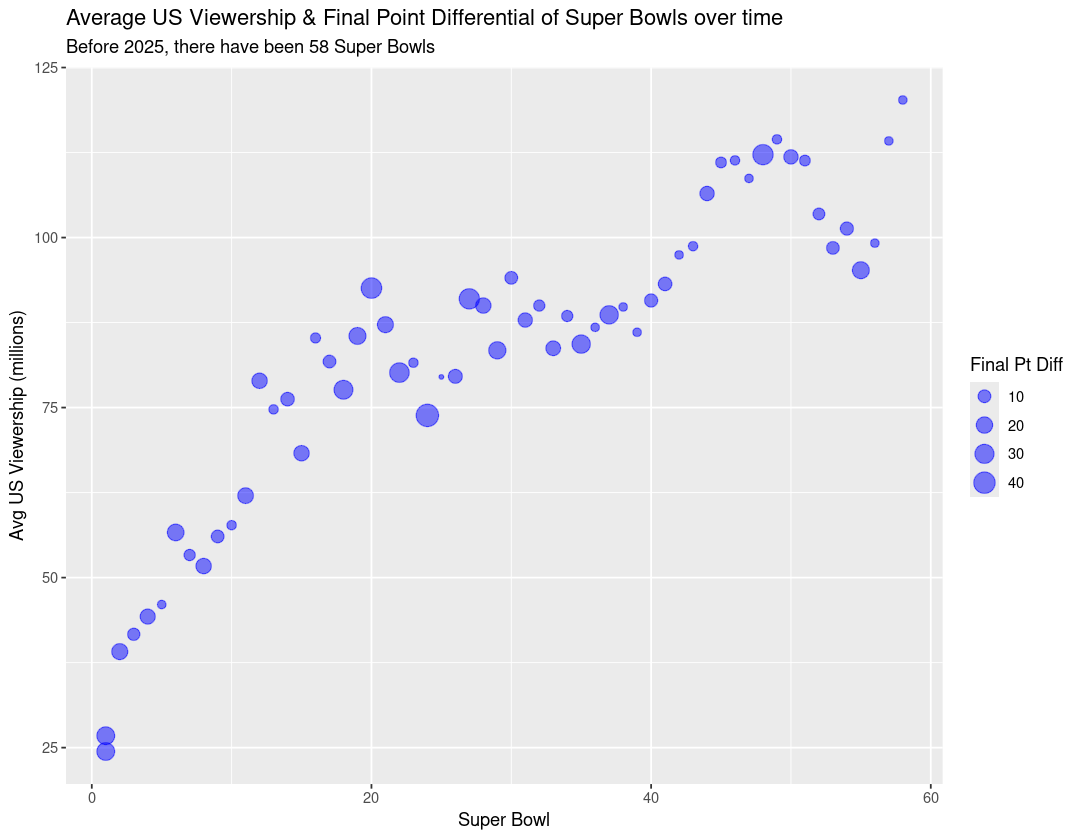

In [197]:
#Q1 cont.

#adjust plot size
options(repr.plot.width = 9, repr.plot.height = 7)
#Plot AVG_US_VIEWERS (millions) vs SUPER_BOWL (over time) w/respect to DIFFERENCE_PTS
q1_plot_III <- ggplot(q1_data, aes(x=super_bowl, y=avg_us_viewers_M, size=difference_pts)) + 
    geom_point(alpha=0.5, color="blue") + 
    labs(title="Average US Viewership & Final Point Differential of Super Bowls over time", x="Super Bowl", 
         y="Avg US Viewership (millions)", size="Final Pt Diff", subtitle="Before 2025, there have been 58 Super Bowls") +
    theme(plot.title=element_text(size=11), plot.subtitle=element_text(size=9), axis.title.x=element_text(size=9), 
          axis.title.y=element_text(size=9), legend.title=element_text(size=9), legend.text=element_text(size=8))
q1_plot_III

Note that in the plot above, the variable along the vertical axis is in units of millions of viewers. This was done to make the values of this axis more readable.

The plot above illustrates how "avg_us_viewership" & "difference_pts" evolved across the 58 Super Bowls. Recall, that a Super Bowl occurs once per year. The size of the points indicate the final point differential--larger dots indicate a larger final point differential.

It is quite clear that average viewership of the Super Bowl increased over time. The games with the least average viewership have greater final point differentials than the games with the highest average viewership, which suggests a negative relatonship between final point differential & average viewership. It is difficult to ascertain the relationship between final point differential and the edition of the Super Bowl (or over time), but it appears that there is no considerable relationship.


Given the correlation between "difference_pts" & "avg_us_viewers"/"total_us_viewers", their relationship is **weakly** negative.

In [198]:
#Q1 concl.
score_impact <- "weak"

# Q2
How has the number of viewers and TV ratings trended alongside advertisement costs? Which one increases first? Visualize and interpret the data, storing your string answer to `first_to_increase` (either "viewers", "ratings", or "ads").

## Part A
*Evaluate "How has the # viewers & TV ratings trended alongside advertisement costs?"*

**Notes:**
- Again, need to merge the 2 datasets together.

### Ad cost vs Avg US viewership

In [199]:
#Q2 A

q2_data <- tv %>%
    #merge the 2 datasets
    full_join(super_bowls, by=c("super_bowl")) %>%
    #change the units of some columns: viewers to millions, ad_cost to 10,000's
    mutate(avg_us_viewers_M = avg_us_viewers/1000000, total_us_viewers_M = total_us_viewers/1000000, ad_cost_10000 = ad_cost/10000) %>%
    #select columns of interest
    select(super_bowl, date, network, avg_us_viewers_M, total_us_viewers_M, rating_household, share_household, rating_18_49, share_18_49, ad_cost_10000)
q2_data

super_bowl,date,network,avg_us_viewers_M,total_us_viewers_M,rating_household,share_household,rating_18_49,share_18_49,ad_cost_10000
<dbl>,<date>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
58,2024-02-11,CBS,120.230,NA,42.1,81,35.9,111,700.0000
57,2023-02-12,Fox,114.210,NA,40.4,NA,33.8,NA,700.0000
56,2022-02-13,NBC,99.180,NA,36.9,72,29.5,NA,650.0000
55,2021-02-07,CBS,95.200,NA,38.2,68,26.5,88,550.0000
54,2020-02-02,Fox,101.320,NA,41.6,69,30.1,77,540.0000
53,2019-02-03,CBS,98.480,NA,41.1,67,31.0,78,520.0000
52,2018-02-04,NBC,103.470,NA,43.1,68,33.4,78,520.0000
51,2017-02-05,Fox,111.319,172.00,45.3,73,37.1,79,500.0000
50,2016-02-07,CBS,111.864,167.00,46.6,72,37.7,79,500.0000


`geom_smooth()` using formula = 'y ~ x'


[1] 0.7599804

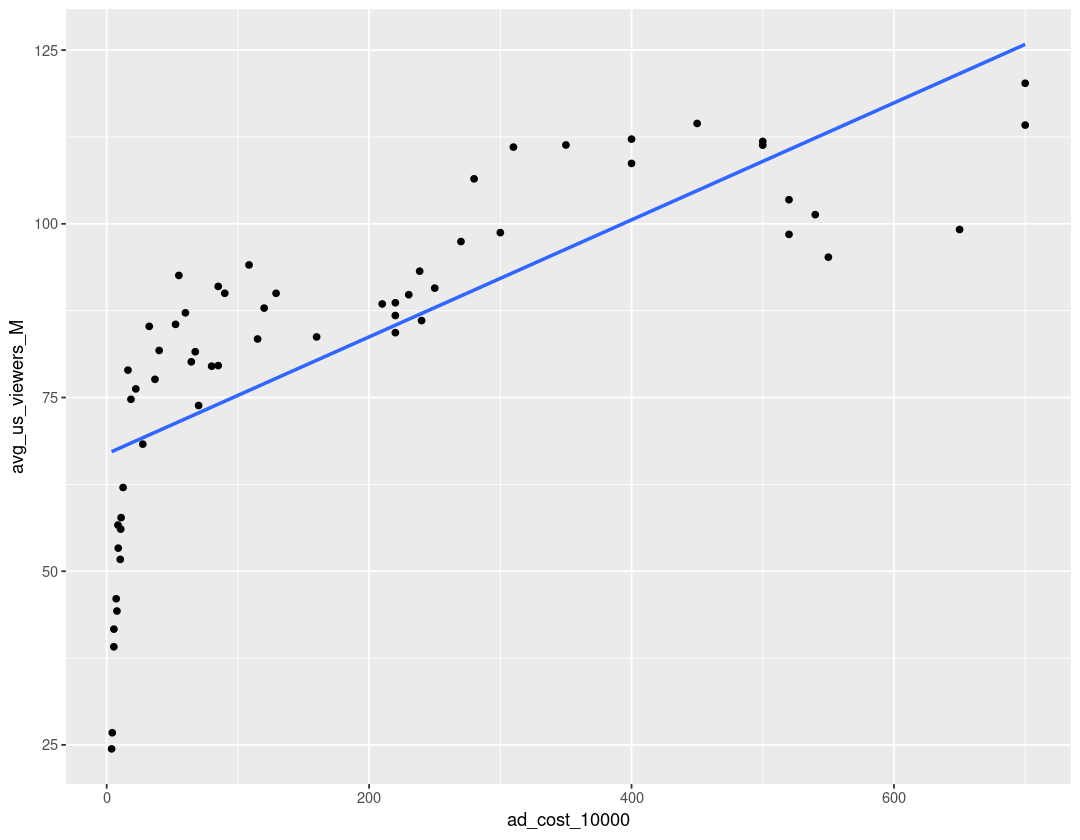

In [200]:
#Q2 A cont.
    #want to visualize #_viewers/tv_ratings vs ad_costs

#make a plot -- AVG_VIEWERS (Millions) vs AD_COST (10,000's)
q2_plot_I <- ggplot(q2_data_A, aes(x=ad_cost_10000, y=avg_us_viewers_M)) + geom_point() + 
  geom_smooth(method="lm", se=FALSE) +
  labs(title="Average Super Bowl Viewership vs Advertisement Cost",
       x="Ad Cost ($10,000)", y="Average US Viewership (millions)") +
  theme(plot.title=element_text(size=11), axis.title.x=element_text(size=10), 
        axis.title.y=element_text(size=10))
q2_plot_I

#calculate correlation
q2_corI <- cor(q2_data_A$ad_cost_10000, q2_data_A$avg_us_viewers_M)
q2_corI
  #OUTPUT: 0.7599804

Note that in the plot above, the horizontal axis is in units 10,000's of whatever the local currency is, presumably Canadian dollars. Additionally, the vertical axis is in units of millions of viewers. This was done to make the values along the axes more readable.

From this plot, it is quite clear that "ad_cost" & "avg_us_viewers" are positively related. This is reinforced by their correlation (~ 0.760), which suggests that these two variables are strongly positively correlated. The sinusoidal (wave-like) motion is intriguing. Perhaps it suggests that there are levels/ranges of "ad_cost" in which the "avg_us_viewership" can plateau, & in order to reach a new high, a new, higher range of "ad_cost" must be sacrificed.

`geom_smooth()` using formula = 'y ~ x'


[1] 0.7599804

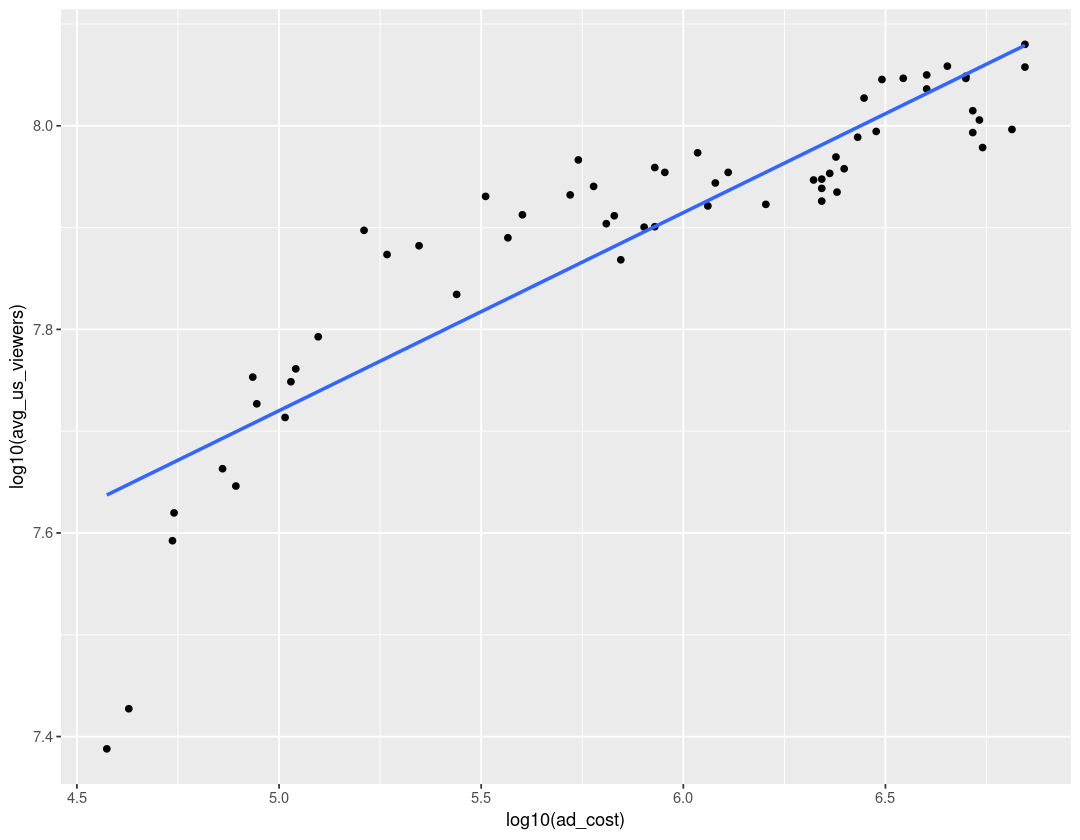

In [201]:
#Q2 A cont.
    #get same data as "q2_data" but without modifying the viewers, ad_cost columns
q2_dataA_alt <- tv %>%
  #merge the 2 datasets
  full_join(super_bowls, by=c("super_bowl")) %>%
  #select columns of interest
  select(super_bowl, date, network, avg_us_viewers, total_us_viewers, 
         rating_household, share_household, rating_18_49, share_18_49, ad_cost)

#Plot LOG10 of AVG_VIEWERS vs LOG10 of AD_COST
q2_plot_II <- ggplot(q2_dataA_alt, aes(x=log10(ad_cost), y=log10(avg_us_viewers))) + 
  geom_point() + geom_smooth(se=FALSE, method="lm") +
  labs(title="Average Super Bowl Viewership vs Advertisement Cost",
       x="Ad Cost (Log10)", y="Average US Viewership (Log10)") +
  theme(plot.title=element_text(size=11), axis.title.x=element_text(size=10), 
        axis.title.y=element_text(size=10))
q2_plot_II

#calculate correlation
q2_corII <- cor(q2_dataA_alt$ad_cost, q2_dataA_alt$avg_us_viewers)
q2_corII
  #OUTPUT: 0.7599804

Note that in the plot above, both axes have had a base-10 logarithm applied to them in order to make them more readable. Otherwise, it displays the same information as the previous plot does.

### Ad cost vs TV ratings
Regarding TV ratings, it wouldn't be appropriate to use "rating_18_49"/"share_18_49" because they have too many missing values. It is most appropriate to use "rating_household" (0 missing values); "share_household" has 1 missing value.

`geom_smooth()` using formula = 'y ~ x'


[1] 0.06802466

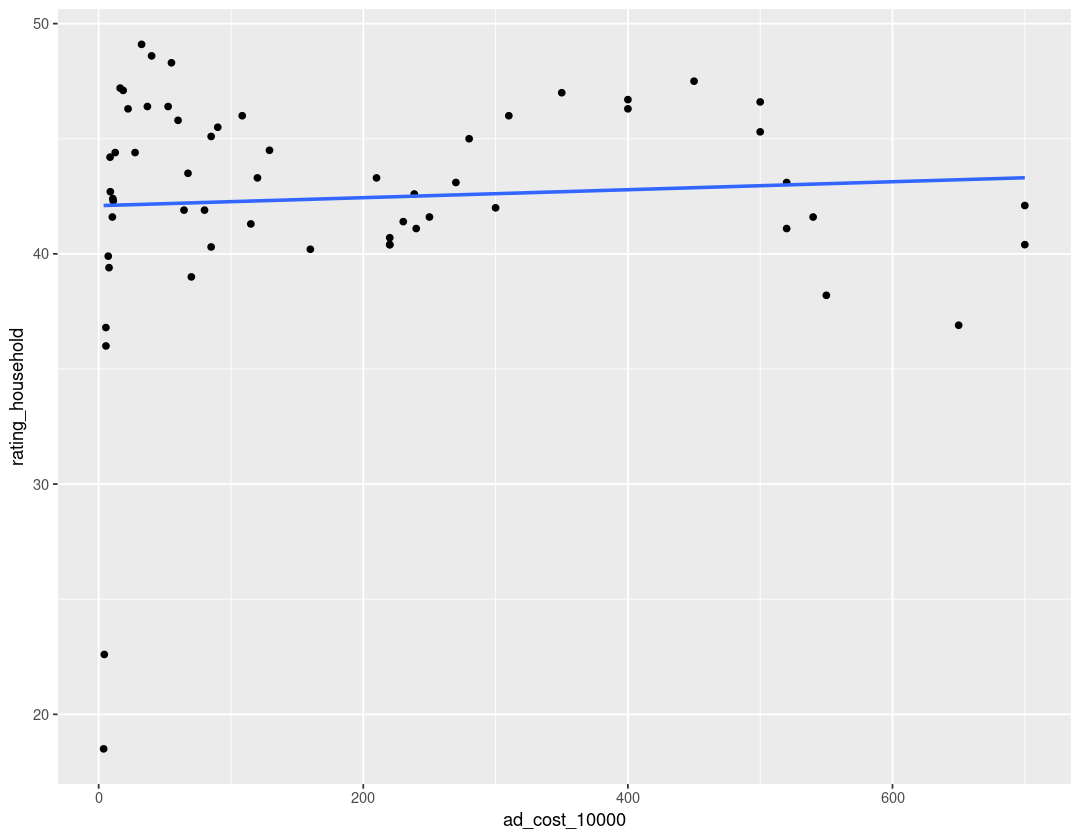

In [202]:
#Q2 A cont.

#Plot RATING_HOUSEHOLD vs AD_COST (10,000's)
q2_plot_III <- ggplot(q2_data_A, aes(x=ad_cost_10000, y=rating_household)) + geom_point() +
  geom_smooth(se=FALSE, method="lm") + 
  labs(title="Percentage Households that Viewed the Super Bowl vs Ad Cost",
       x="Ad Cost ($10,000)", y="% Households that Watched") +
  theme(plot.title=element_text(size=11), axis.title.x=element_text(size=10),
        axis.title.y=element_text(size=10))
q2_plot_III

#calculate correlation
q2_corIII <- cor(q2_data_A$ad_cost_10000, q2_data_A$rating_household)
q2_corIII
  #OUTPUT: 0.06802466

Note that in the plot above, the horizontal axis is in units 10,000's of whatever the local currency is, presumably Canadian dollars.

From this plot, there is no definitive relationship between the two variables, which is reinforced by their correlation (~ 0.068). As such, it is likely that these variables have no meaningful relationship. The smallest & largest TV ratings are at very small advertisement costs. The rate in which "rating_household" increases at lowest values of "ad_cost" is difficult to decipher. As such, a logarithm was applied to the horizontal axis in the hopes that it might make the data more readable. This is seen in the following plot.

`geom_smooth()` using formula = 'y ~ x'


[1] 0.06802466

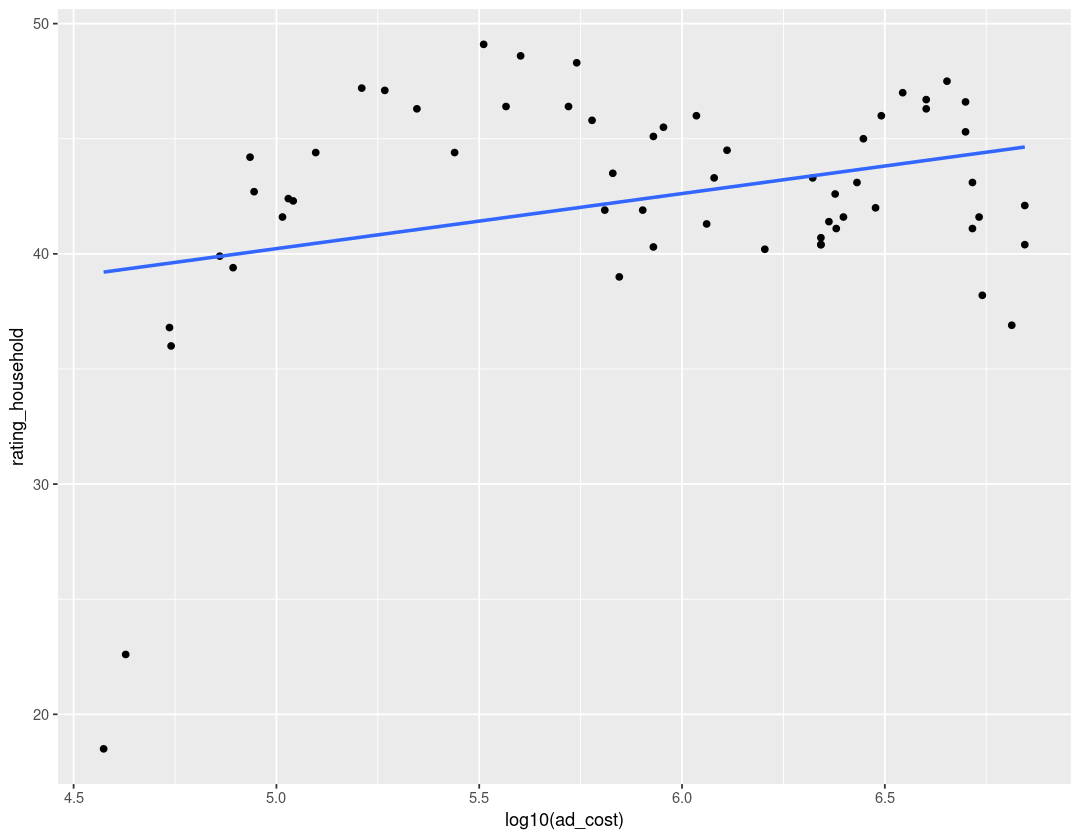

In [203]:
#Q2 A cont.

#make a plot using the non-modified data -- Plot RATING HOUSEHOLD vs LOG10 of AD_COST
q2_plot_IV <- ggplot(q2_dataA_alt, aes(x=log10(ad_cost), y=rating_household)) + geom_point() +
  geom_smooth(se=FALSE, method="lm") +
  labs(title="Percentage Households that Viewed the Super Bowl vs Ad Cost",
       x="Ad Cost (Log10)", y="% Households that Watched") +
  theme(plot.title=element_text(size=11), axis.title.x=element_text(size=10),
        axis.title.y=element_text(size=10))
q2_plot_IV

#calculate correlation
q2_corIV <- cor(q2_dataA_alt$ad_cost, q2_dataA_alt$rating_household)
q2_corIV
  #OUTPUT: 0.06802466

Note that in the plot above, the horizontal axis has had a base-10 logarithm applied to it in order to make it more readable. Otherwise, it displays the same information as the previous plot does.

At first, an increase in "ad_cost" clearly leads to higher "rating_household" ratings; however, at an "ad_cost" of about 10^5.5, these ratings reach their peak. This suggests that more expensive ads lead to higher Super Bowl ratings than cheaper ads, but too expensive ads can backfire in terms of TV ratings.

## Part B
Evaluate "Which variable increases first?"

**Notes:**
- By "variable", the prompt is asking between: viewers, ratings, or ads.
- Q2 A evaluated all SB's. Between "ad_cost" & "avg_us_viewers", there is a strong, positive correlation (~ 0.760). Between "ad_cost" & "rating_household", there is a weak correlation (~ 0.069). BUT, from the plots, both variables increase quite quickly with respect to "ad_cost." So, trimming down to the early (~ 5-10) SB's could help identify the answer to this question.
- Recall that for SB 1, there are 2 observations because there is data for 2 different "network"s. Should sum/avg the relevant values into a single observation.

In [204]:
#Q2 B
q2B_data_I <- tv %>%
    #merge the 2 datasets
    full_join(super_bowls, by=c("super_bowl")) %>%
    #filter for the first 10 SB's
    filter(super_bowl <= 10) %>%
    #select columns of interest
    select(super_bowl, avg_us_viewers, rating_household, share_household, ad_cost)
q2B_data_I

super_bowl,avg_us_viewers,rating_household,share_household,ad_cost
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10,57710000,42.3,78,110000
9,56050000,42.4,72,107000
8,51700000,41.6,73,103500
7,53320000,42.7,72,88100
6,56640000,44.2,74,86100
5,46040000,39.9,75,72500
4,44270000,39.4,69,78200
3,41660000,36.0,70,55000
2,39120000,36.8,68,54500


In the data above, there are two observations for Super Bowl 1, which is due to the fact that both the CBS & NBC networks covered the game. For the purposes of the question at hand, the relevant statistics of these two observations need to be coalesced into one. For "avg_us_viewers" & "ad_cost", get the sum as if only one network covered the game. For "rating_household" & "share_household" get the average. These specific columns were selected because they were the most relevant & they did not have missing values.

In [205]:
#Q2 B cont.
#fix SB 1 data
q2B_SB1 <- q2B_data_I %>%
    #filter for SB 1
    filter(super_bowl == 1) %>%
    #calculate statistics for columns of interest
    summarize(super_bowl = super_bowl, avg_us_viewers = sum(avg_us_viewers), rating_household = mean(rating_household), share_household = mean(share_household), ad_cost = sum(ad_cost))
#remove the duplicate row
q2B_SB1 <- q2B_SB1[-1,]
#q2B_SB1

#impute this new data into the original data for SB 1
q2B_data_II <- q2B_data_I %>%
    #select SB's 2-10
    filter(super_bowl != 1) %>%
    #add new SB 1 data
    bind_rows(q2B_SB1)
q2B_data_II


Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in
dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()`
  always returns an ungrouped data frame and adjust accordingly.”


super_bowl,avg_us_viewers,rating_household,share_household,ad_cost
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10,57710000,42.30,78.0,110000
9,56050000,42.40,72.0,107000
8,51700000,41.60,73.0,103500
7,53320000,42.70,72.0,88100
6,56640000,44.20,74.0,86100
5,46040000,39.90,75.0,72500
4,44270000,39.40,69.0,78200
3,41660000,36.00,70.0,55000
2,39120000,36.80,68.0,54500


With this data, it can be determined "which variable, of viewers, ratings, or ad costs increased first." As such, only consider the first two Super Bowls--1 & 2. From Super Bowl 1 to 2:
- The variable "avg_us_viewers" decreased from ~ 51.2 million to ~ 39.12 million.
- The variables "rating_household" & "share_household" both increased from 20.55 to 36.80 & 39.5 to 68.0 respectively.
- The variable "ad_cost" decreases from 80,000 to 54,500 units of currency, presumably Canadian dollars.

As such, of these three variables--viewers, ratings, ad costs--the ratings increased first.

In [206]:
#Q2 concl. --- assign specified variable

first_to_increase <- "ratings"